In [41]:
from pathlib import Path
import pandas as pd

# '..' means "go up one folder" to the project root
data_path = Path("..") / "data" / "output.csv"

# Load your df
df = pd.read_csv(data_path)

images_path = Path("..") / "results"


In [42]:
df.head()

,id,condition,sentiment,uncertainty,resolution,first_sentence,second_sentence,sentiment_1,valence_1,sentiment_2,valence_2,pair_uncertainty,pair_resolution
0,1,PosHghNoUnc,positive,low,low,Leo a commandé un écran sur Amazon.,Il reçoit son colis après 2 jours ouvrables co...,0.0,0.3,0.1,0.70,0.8,0.0
1,2,PosHghNoUnc,positive,low,low,Jade se balade avec une amie.,Elles parlent de leur journée.,0.3,0.6,0.4,0.70,0.1,0.5
2,3,PosHghNoUnc,positive,low,low,Sam est sur Tinder.,Il croise des profils différents et décide s'i...,0.0,0.3,0.1,0.45,0.8,0.0
3,4,PosHghNoUnc,positive,low,low,"Dernièrement, John suit un régime alimentaire ...",Il se sent en meilleure santé et il a perdu 3 kg.,0.3,0.6,0.7,0.90,0.1,1.0
4,5,PosHghNoUnc,positive,low,low,Lisa a travaillé assidûment pour sa thèse de m...,Elle a eu une très bonne note: 85%!.,0.7,0.9,0.9,0.95,0.3,0.8


# valence - sentiment plot

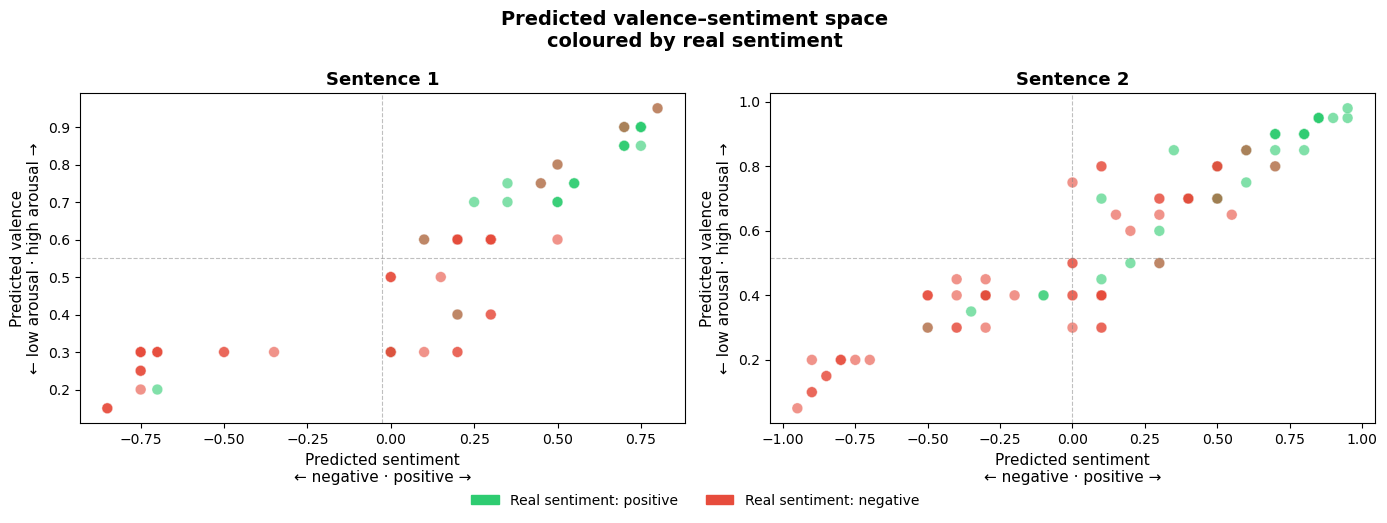

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pairs = [
    ('sentiment_1', 'valence_1', 'Sentence 1'),
    ('sentiment_2', 'valence_2', 'Sentence 2'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (sent_col, val_col, title) in zip(axes, pairs):
    subset = df[['sentiment', sent_col, val_col]].dropna().copy()
    subset[sent_col] = subset[sent_col].astype(float)
    subset[val_col]  = subset[val_col].astype(float)

    colors = subset['sentiment'].map({'positive': '#2ecc71', 'negative': '#e74c3c'}).tolist()

    ax.scatter(subset[sent_col], subset[val_col],
               c=colors, alpha=0.6, edgecolors='white', linewidths=0.4, s=60)

    mid_x = (subset[sent_col].max() + subset[sent_col].min()) / 2
    mid_y = (subset[val_col].max() + subset[val_col].min()) / 2
    ax.axhline(mid_y, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(mid_x, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

    ax.set_xlabel('Predicted sentiment\n← negative · positive →', fontsize=11)
    ax.set_ylabel('Predicted valence\n← low arousal · high arousal →', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')

legend_handles = [
    mpatches.Patch(color='#2ecc71', label='Real sentiment: positive'),
    mpatches.Patch(color='#e74c3c', label='Real sentiment: negative'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Predicted valence–sentiment space\ncoloured by real sentiment',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(images_path / 'valence_sentiment_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# let's make it binary

In [25]:
df_an = df.copy()

df_an["sentiment"] = df_an["sentiment"].apply(lambda x: int(1) if x == "positive" else int(0) if x == "negative" else pd.NA)
df_an["uncertainty"] = df_an["uncertainty"].apply(lambda x: int(1) if x == "high" else int(0) if x == "low" else pd.NA)
df_an["resolution"] = df_an["resolution"].apply(lambda x: int(1) if x == "high" else int(0) if x == "low" else pd.NA)

df_an["sentiment_1"] = df_an["sentiment_1"].apply(lambda x: int(1) if x > 0 else int(0) if x < 0 else pd.NA)
df_an["sentiment_2"] = df_an["sentiment_2"].apply(lambda x: int(1) if x > 0 else int(0) if x < 0 else pd.NA)

df_an["valence_1"] = df_an["valence_1"].apply(lambda x: int(1) if x > 0.5 else int(0) if x < 0.5 else pd.NA)
df_an["valence_2"] = df_an["valence_2"].apply(lambda x: int(1) if x > 0.5 else int(0) if x < 0.5 else pd.NA)

df_an["pair_uncertainty"] = df_an["pair_uncertainty"].apply(lambda x: int(1) if x > 0.5 else int(0) if x < 0.5 else pd.NA)
df_an["pair_resolution"] = df_an["pair_resolution"].apply(lambda x: int(1) if x > 0.5 else int(0) if x < 0.5 else pd.NA)

In [26]:
df_an.head()

,id,condition,sentiment,uncertainty,resolution,first_sentence,second_sentence,sentiment_1,valence_1,sentiment_2,valence_2,pair_uncertainty,pair_resolution
0,1,PosHghNoUnc,1,0,0,Leo a commandé un écran sur Amazon.,Il reçoit son colis après 2 jours ouvrables co...,<NA>,0,1,1,1,0
1,2,PosHghNoUnc,1,0,0,Jade se balade avec une amie.,Elles parlent de leur journée.,1,1,1,1,0,<NA>
2,3,PosHghNoUnc,1,0,0,Sam est sur Tinder.,Il croise des profils différents et décide s'i...,<NA>,0,1,0,1,0
3,4,PosHghNoUnc,1,0,0,"Dernièrement, John suit un régime alimentaire ...",Il se sent en meilleure santé et il a perdu 3 kg.,1,1,1,1,0,1
4,5,PosHghNoUnc,1,0,0,Lisa a travaillé assidûment pour sa thèse de m...,Elle a eu une très bonne note: 85%!.,1,1,1,1,0,1


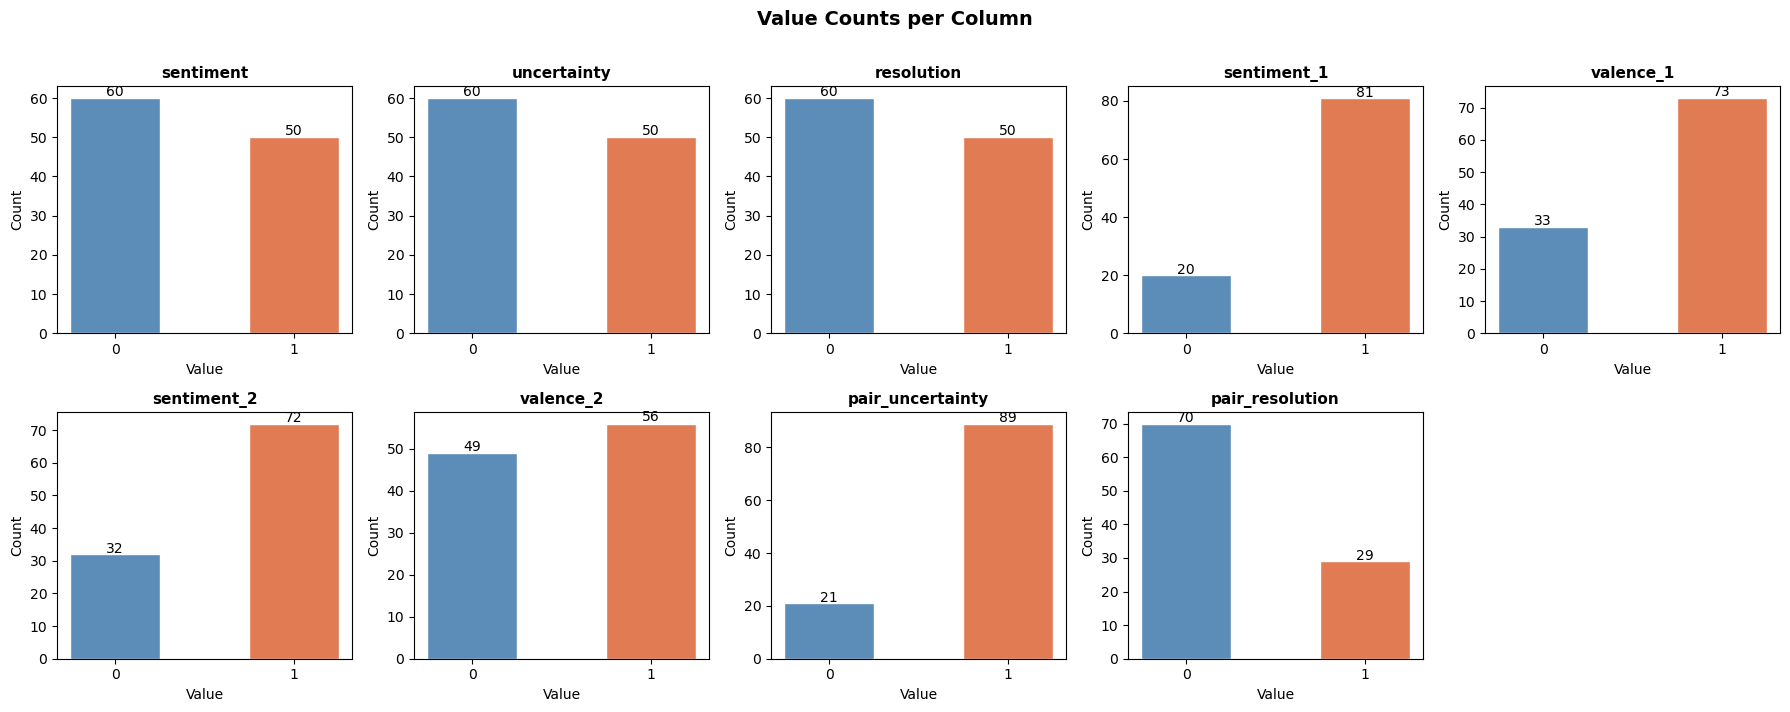

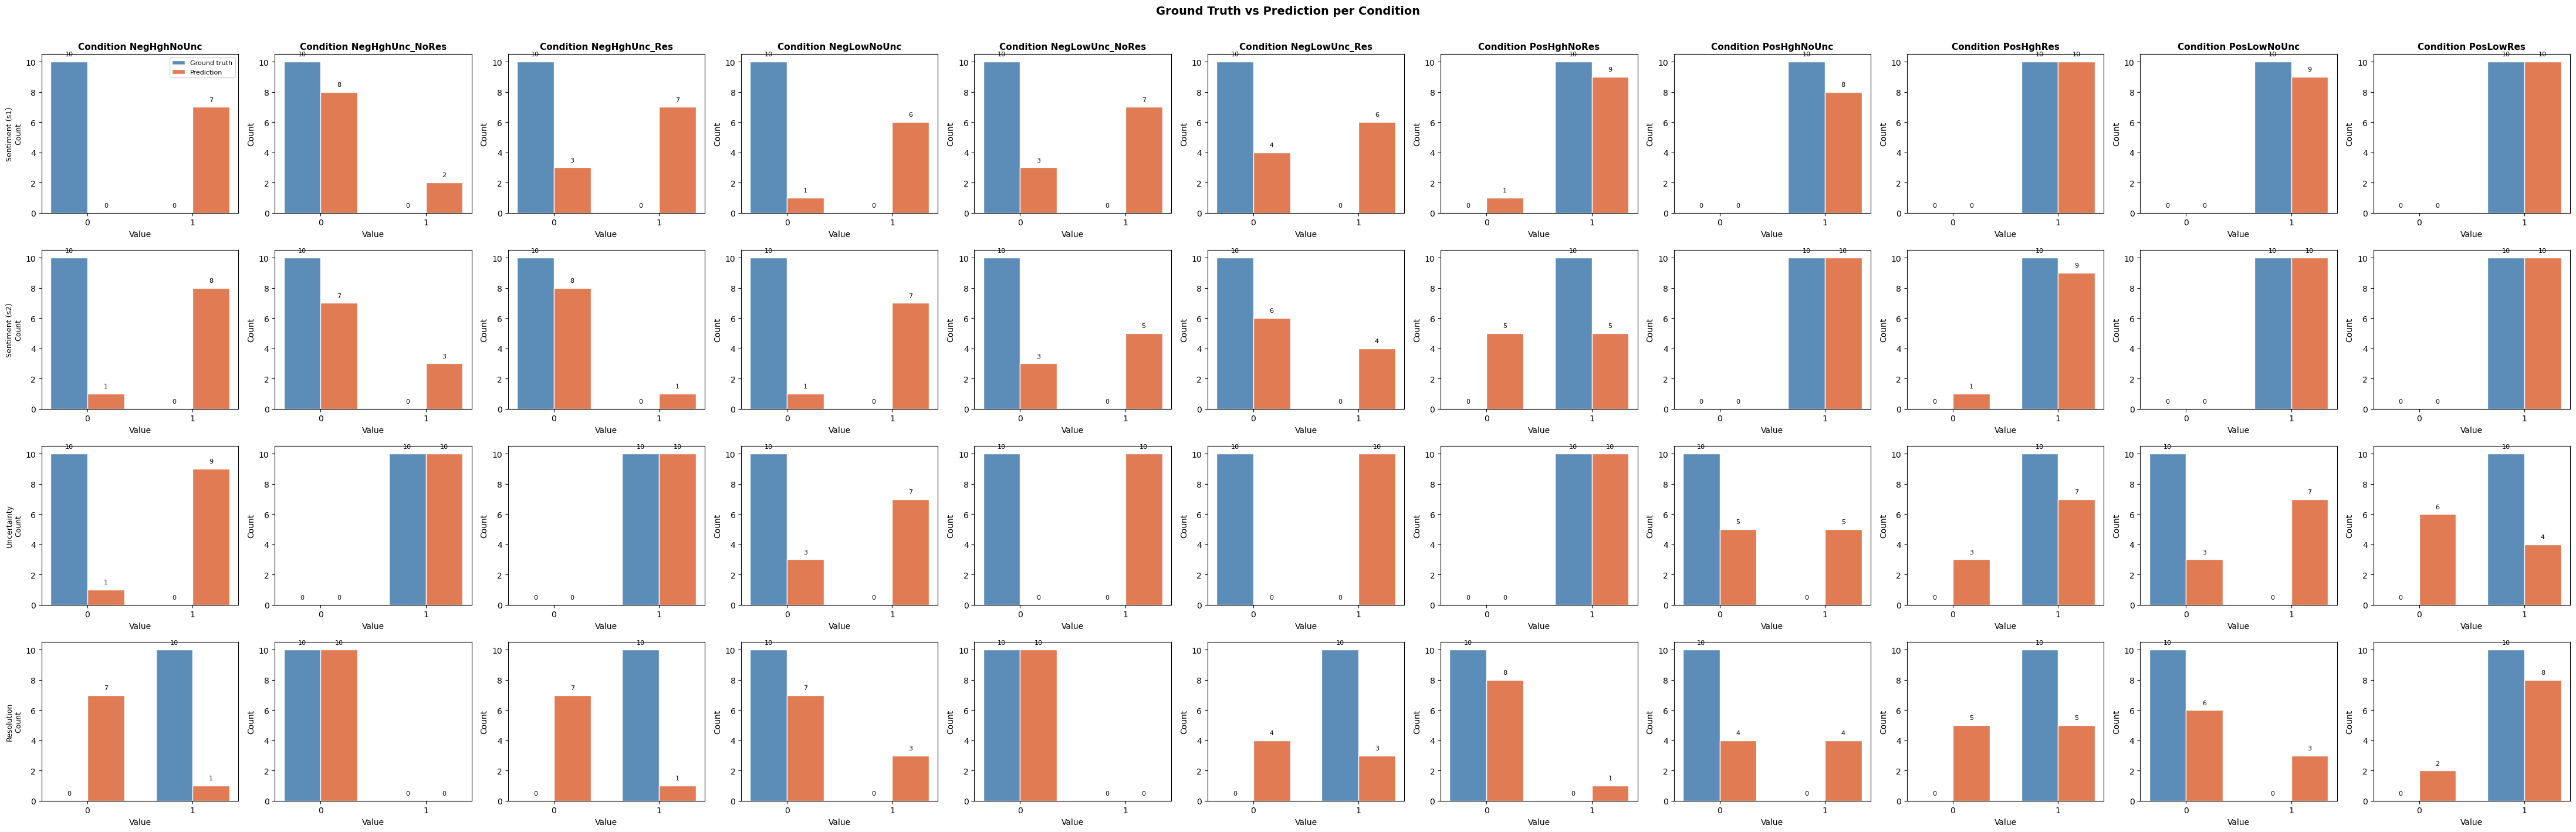

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── 1. Frequency counts per binary column ──────────────────────────────────────
binary_cols = [
    'sentiment', 'uncertainty', 'resolution',
    'sentiment_1', 'valence_1', 'sentiment_2', 'valence_2',
    'pair_uncertainty', 'pair_resolution'
]

n = len(binary_cols)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df_an[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color=['#5B8DB8', '#E07B54'], edgecolor='white', width=0.5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 0.5, str(v), ha='center', fontsize=10)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['0', '1'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Value Counts per Column', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(images_path / 'value_counts.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Ground truth vs prediction per condition ────────────────────────────────
# Pairs: (ground_truth_col, predicted_col, label)
pairs = [
    ('sentiment',    'sentiment_1',     'Sentiment (s1)'),
    ('sentiment',    'sentiment_2',     'Sentiment (s2)'),
    ('uncertainty',  'pair_uncertainty','Uncertainty'),
    ('resolution',   'pair_resolution', 'Resolution'),
]

conditions = sorted(df_an['condition'].unique())
n_pairs = len(pairs)
n_cond  = len(conditions)

fig, axes = plt.subplots(n_pairs, n_cond, figsize=(n_cond * 4, n_pairs * 3.5), sharey=False)
if n_cond == 1:
    axes = axes.reshape(-1, 1)
if n_pairs == 1:
    axes = axes.reshape(1, -1)

colors = {'Ground truth': '#5B8DB8', 'Prediction': '#E07B54'}
x = np.array([0, 1])
width = 0.35

for row, (gt_col, pred_col, label) in enumerate(pairs):
    for col_idx, cond in enumerate(conditions):
        ax = axes[row][col_idx]
        subset = df_an[df_an['condition'] == cond]

        gt_counts   = subset[gt_col].value_counts().reindex([0, 1], fill_value=0)
        pred_counts = subset[pred_col].value_counts().reindex([0, 1], fill_value=0)

        bars1 = ax.bar(x - width/2, gt_counts.values,   width, label='Ground truth', color=colors['Ground truth'],  edgecolor='white')
        bars2 = ax.bar(x + width/2, pred_counts.values, width, label='Prediction',   color=colors['Prediction'], edgecolor='white')

        for bar in list(bars1) + list(bars2):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, str(int(h)), ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(['0', '1'])
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')

        if row == 0:
            ax.set_title(f'Condition {cond}', fontsize=11, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(f'{label}\nCount', fontsize=9)
        if row == 0 and col_idx == 0:
            ax.legend(fontsize=8)

fig.suptitle('Ground Truth vs Prediction per Condition', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(images_path / 'gt_vs_pred_per_condition.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix 

True sentiment vs sentiment_1: 9/110 rows dropped due to NA (8.2%)
True sentiment vs sentiment_2: 6/110 rows dropped due to NA (5.5%)
Uncertainty vs pair_uncertainty: 0/110 rows dropped due to NA (0.0%)
Resolution vs pair_resolution: 11/110 rows dropped due to NA (10.0%)


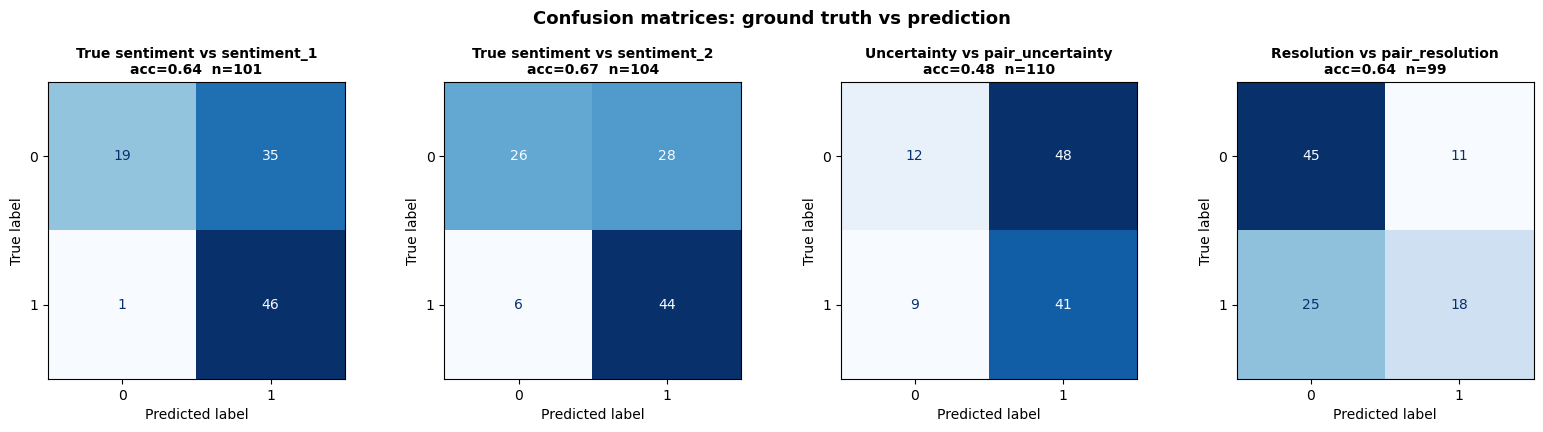

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pairs = [
    ('sentiment',  'sentiment_1',        'True sentiment vs sentiment_1'),
    ('sentiment',  'sentiment_2',        'True sentiment vs sentiment_2'),
    ('uncertainty',  'pair_uncertainty', 'Uncertainty vs pair_uncertainty'),
    ('resolution',   'pair_resolution',  'Resolution vs pair_resolution'),
]

n = len(pairs)
fig, axes = plt.subplots(1, n, figsize=(n * 4, 4))

for ax, (gt_col, pred_col, title) in zip(axes, pairs):
    subset = df_an[[gt_col, pred_col]].copy()
    
    before = len(subset)
    subset = subset.dropna()
    dropped = before - len(subset)
    
    print(f"{title}: {dropped}/{before} rows dropped due to NA ({dropped/before:.1%})")
    
    y_true = subset[gt_col].astype(int)
    y_pred = subset[pred_col].astype(int)
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    
    acc = np.trace(cm) / cm.sum()
    ax.set_title(f"{title}\nacc={acc:.2f}  n={len(subset)}", fontsize=10, fontweight='bold')

fig.suptitle('Confusion matrices: ground truth vs prediction', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(images_path / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# F1 scores

In [ ]:
from sklearn import metrics

CONDITION = "sentiment"

for i in (1, 2):
    df_filtered = df_an[df_an[f"{CONDITION}_{i}"].notna() & df_an[CONDITION].notna()].copy()

    y_true = df_filtered[CONDITION].astype(int)
    y_pred = df_filtered[f"{CONDITION}_{i}"].astype(int)

    f1_score = metrics.f1_score(y_true, y_pred, average="binary")
    print(f'F1 Score for the sentiment {i}: {f1_score}')

F1 Score for the sentiment 1: 0.71875
F1 Score for the sentiment 2: 0.7213114754098361


In [35]:
CONDITIONS = ["uncertainty", "resolution"]

for CONDITION in CONDITIONS:
    df_filtered = df_an[df_an[f"pair_{CONDITION}"].notna() & df_an[CONDITION].notna()].copy()

    y_true = df_filtered[CONDITION].astype(int)
    y_pred = df_filtered[f"pair_{CONDITION}"].astype(int)

    f1_score = metrics.f1_score(y_true, y_pred, average="binary")
    print(f'F1 Score for the {CONDITION}: {f1_score}')

F1 Score for the uncertainty: 0.5899280575539568
F1 Score for the resolution: 0.5
